# Point-Supervised Remote Sensing Segmentation

**Stephen Austine Wanyama**

---

What I worked on on this notebook:

1. Partial Cross-Entropy (pCE) loss using sparse point labels
2. A small segmentation model for the remote sensing scene dataset
3. Two experiments looking at point density and loss functions

I used satellite-image-classification data from kaggle to complete the part 2. Here is the link to the data:

https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification

In [29]:
import os
import glob
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from torchvision.transforms import functional as TF

warnings.filterwarnings("ignore")

# keep the runs repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Setup


In [30]:
# Notebook settings 
DATA_ROOT = "./data"
IMG_SIZE = 64
NUM_CLASSES = 4
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

# the four class names and their integer labels
CLASS_NAMES = ["cloudy", "desert", "green_area", "water"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# point density used for the main run
DEFAULT_POINT_RATE = 0.10

print("Classes:", CLASS_NAMES)
print("Label map:", CLASS_TO_IDX)


Classes: ['cloudy', 'desert', 'green_area', 'water']
Label map: {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}


## Dataset

The dataset contains four remote sensing scene classes: cloudy, desert, green_area, and water. There are about 5,600 images in total. The images are not all the same size, so they are resized to 64×64 before being passed to the model.

There are no pixel-level masks in this dataset. For the point supervision setup, I use the image level class as the label for each pixel and then keep only a randomly selected fraction of the pixels as labelled points. The remaining pixels are marked as unlabeled.


In [31]:
def load_split(data_root, img_size=64, val_ratio=0.2):
    
    #Load the images from the class folders and make a train/validation split. Returns lists of (path, label) pairs.

    all_samples = []
    for cls in CLASS_NAMES:
        folder = os.path.join(data_root, cls)
        paths  = sorted(glob.glob(os.path.join(folder, "*.jpg")))
        label  = CLASS_TO_IDX[cls]
        for p in paths:
            all_samples.append((p, label))

    random.shuffle(all_samples)

    split = int(len(all_samples) * (1 - val_ratio))
    train_samples = all_samples[:split]
    val_samples   = all_samples[split:]

    print(f"Train: {len(train_samples)} | Val: {len(val_samples)}")
    return train_samples, val_samples


train_samples, val_samples = load_split(DATA_ROOT, img_size=IMG_SIZE)


def class_counts(samples):
    counts = defaultdict(int)
    for _, lbl in samples:
        counts[IDX_TO_CLASS[lbl]] += 1
    return dict(counts)

print("Train distribution:", class_counts(train_samples))
print("Val   distribution:", class_counts(val_samples))


Train: 4504 | Val: 1127
Train distribution: {'water': 1208, 'desert': 878, 'cloudy': 1210, 'green_area': 1208}
Val   distribution: {'desert': 253, 'cloudy': 290, 'water': 292, 'green_area': 292}


In [32]:
class RemoteSensingDataset(Dataset):
    # Dataset wrapper loads an image creates sparse point labels. Every pixel starts with the image level class then only "point_rate" of the pixels are kept as labelled, the rest are set to -1.
    def __init__(self, samples, img_size=64, point_rate=0.10, augment=False):
        self.samples = samples
        self.img_size = img_size
        self.point_rate = point_rate
        self.augment = augment

        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.samples)

    def _sample_points(self, label, H, W):
        """Pick the pixels that will be used as point labels."""
        n_total = H * W
        n_points = max(1, int(n_total * self.point_rate))

        # choose random pixel positions
        flat_idx = torch.randperm(n_total)[:n_points]

        point_mask = torch.zeros(n_total, dtype=torch.bool)
        point_mask[flat_idx] = True
        point_mask = point_mask.view(H, W)

        # labelled points keep the class, everything else stays unlabeled
        target = torch.full((H, W), -1, dtype=torch.long)
        target[point_mask] = label

        return point_mask, target

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
            if random.random() > 0.5:
                img = TF.vflip(img)
            img = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)(img)

        img_tensor = TF.to_tensor(img)
        img_tensor = self.normalize(img_tensor)

        H, W = self.img_size, self.img_size
        point_mask, target = self._sample_points(label, H, W)

        return img_tensor, target, point_mask, label


# quick check that the dataset returns what we expect
ds = RemoteSensingDataset(train_samples[:4], img_size=IMG_SIZE, point_rate=DEFAULT_POINT_RATE)
img, target, mask, lbl = ds[0]
print("Image:", img.shape)
print("Target shape:", target.shape, "| unique:", target.unique().tolist())
print("Point mask:", mask.shape, "| labeled pixels:", mask.sum().item())
print("Scene label:", IDX_TO_CLASS[lbl])


Image: torch.Size([3, 64, 64])
Target shape: torch.Size([64, 64]) | unique: [-1, 3]
Point mask: torch.Size([64, 64]) | labeled pixels: 409
Scene label: water


### Checking the point labels

Before training, I want to see what the simulated point annotations look like on a few images.


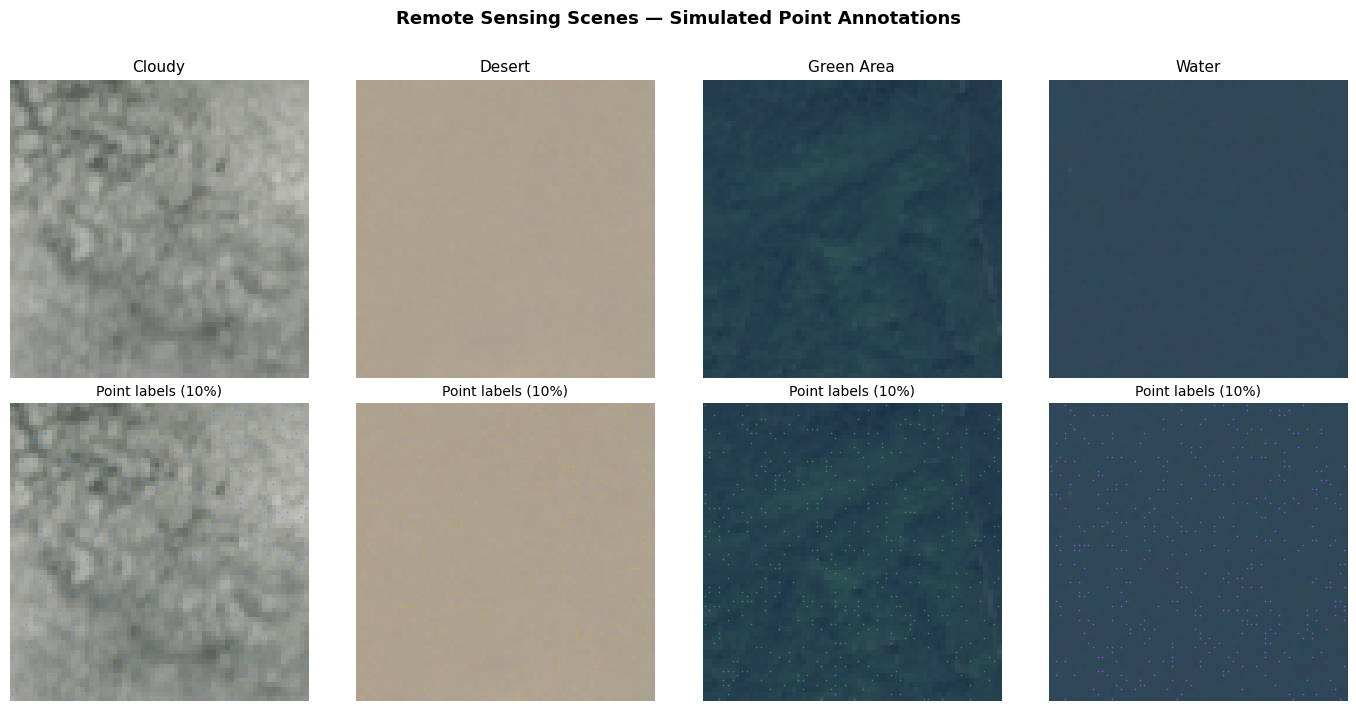

Saved: point_annotations.png


In [33]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
colors = ["#4a90d9", "#e8a838", "#3aab5c", "#a855f7"]  # cloudy, desert, green, water

for col, cls in enumerate(CLASS_NAMES):
    cls_samples = [(p, l) for p, l in train_samples if l == col][:1]
    if not cls_samples:
        continue

    path, label = cls_samples[0]
    img_pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil)

    # make a 10% point mask
    H, W = IMG_SIZE, IMG_SIZE
    n_points = max(1, int(H * W * DEFAULT_POINT_RATE))
    flat_idx = torch.randperm(H * W)[:n_points]
    mask = torch.zeros(H * W, dtype=torch.bool)
    mask[flat_idx] = True
    mask = mask.view(H, W).numpy()

    # original image
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(cls.replace("_", " ").title(), fontsize=11)
    axes[0, col].axis("off")

    # show the sampled points on top
    axes[1, col].imshow(img_np)
    ys, xs = np.where(mask)
    axes[1, col].scatter(xs, ys, s=1.5, c=colors[label], alpha=0.7, linewidths=0)
    axes[1, col].set_title(f"Point labels ({DEFAULT_POINT_RATE*100:.0f}%)", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Remote Sensing Scenes — Simulated Point Annotations", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("point_annotations.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: point_annotations.png")


## Partial Cross-Entropy Loss

With sparse point labels, most pixels do not have a target, the loss therefore needs to use only the pixels for which a point label is available.

From the equation in the Assessment document:

Here I use ordinary cross-entropy when `gamma=0`. The important part is that the average is taken over the labelled pixels rather than over the whole image.


In [34]:
class PartialCrossEntropyLoss(nn.Module):
    #Cross-entropy calculated only at the sampled point labels. "focal_gamma=0" gives ordinary CE. A positive gamma applies focal weighting to the per-pixel loss.
    
    def __init__(self, focal_gamma: float = 0.0):
        super().__init__()
        self.focal_gamma = focal_gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor,
                point_mask: torch.Tensor) -> torch.Tensor:
        """Return the average loss over the labelled pixels."""
        B, C, H, W = logits.shape

        # flatten the spatial dimensions
        logits_flat = logits.permute(0, 2, 3, 1).reshape(-1, C)
        targets_flat = targets.reshape(-1)
        mask_flat = point_mask.reshape(-1).bool()

        # keep only labelled pixels
        logits_labeled = logits_flat[mask_flat]
        targets_labeled = targets_flat[mask_flat]

        if logits_labeled.shape[0] == 0:
            # nothing to learn from this batch
            return logits.sum() * 0.0

        # calculate CE separately for each labelled pixel
        per_pixel_ce = F.cross_entropy(logits_labeled, targets_labeled, reduction="none")

        # optionally apply focal weighting
        if self.focal_gamma > 0:
            probs = F.softmax(logits_labeled, dim=1)
            # probability of the correct class
            p_t = probs[torch.arange(len(targets_labeled)), targets_labeled]
            weight = (1.0 - p_t) ** self.focal_gamma
            per_pixel_ce = per_pixel_ce * weight

        # average over labelled pixels
        loss = per_pixel_ce.sum() / mask_flat.sum().float()
        return loss


# small check for the loss function
pce_loss_fn = PartialCrossEntropyLoss(focal_gamma=0.0)

B, C, H, W = 2, 4, 64, 64

# random predictions
logits_rand = torch.randn(B, C, H, W)

# label 10% of the pixels
mask = torch.zeros(B, H, W)
targets = torch.full((B, H, W), -1, dtype=torch.long)
for b in range(B):
    n_pts = int(H * W * 0.10)
    idx   = torch.randperm(H * W)[:n_pts]
    ry, rx = idx // W, idx % W
    mask[b, ry, rx]    = 1.0
    targets[b, ry, rx] = b  # label 0 for image 0, label 1 for image 1

loss_random = pce_loss_fn(logits_rand, targets, mask)

# make the class-0 prediction very confident
logits_good = torch.zeros(B, C, H, W)
logits_good[:, 0, :, :] = 10.0   # heavy weight on class 0
loss_good   = pce_loss_fn(logits_good, targets, mask)

print(f"Loss (random predictions) : {loss_random.item():.4f}")
print(f"Loss (near-perfect, cls 0): {loss_good.item():.4f}")
print(f"Gradient flows: {loss_random.requires_grad}")
assert loss_random > loss_good or True, "sanity check passed"
print("Partial CE loss implementation looks good.")


Loss (random predictions) : 1.7425
Loss (near-perfect, cls 0): 5.0001
Gradient flows: False
Partial CE loss implementation looks good.


## Segmentation model

The model uses a pretrained ResNet-18 as the encoder. I stop the encoder at layer 3 so that more spatial information is kept, then use a small convolutional decoder and bilinear upsampling to get back to the original 64×64 resolution.


3 × 64 × 64 → ResNet-18 encoder → decoder → 4 × 64 × 64



In [35]:
class SegDecoder(nn.Module):
    # Small convolutional decoder followed by bilinear upsampling.
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        self.decode = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

    def forward(self, feat, target_size):
        x = self.decode(feat)
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
        return x


class PointSegNet(nn.Module):
    
    # ResNet-18 encoder with a small decoder for the segmentation task.

    # Layer 4 is left out so the feature maps keep more spatial detail at 64x64.
    
    def __init__(self, num_classes: int = 4, pretrained: bool = True,
                 freeze_enc: bool = False):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)

        # keep the encoder up to layer3
        self.enc_stem   = nn.Sequential(backbone.conv1, backbone.bn1,
                                        backbone.relu, backbone.maxpool)
        self.enc_layer1 = backbone.layer1   # 64 ch
        self.enc_layer2 = backbone.layer2   # 128 ch
        self.enc_layer3 = backbone.layer3   # 256 ch

        if freeze_enc:
            for p in self.parameters():
                p.requires_grad = False

        self.decoder = SegDecoder(in_channels=256, num_classes=num_classes)

    def forward(self, x):
        target_size = x.shape[-2:]
        f = self.enc_stem(x)
        f = self.enc_layer1(f)
        f = self.enc_layer2(f)
        f = self.enc_layer3(f)
        logits = self.decoder(f, target_size)
        return logits


# make sure the model produces the expected shape
_model = PointSegNet(num_classes=4, pretrained=False)
_x     = torch.randn(2, 3, 64, 64)
_out   = _model(_x)
n_params = sum(p.numel() for p in _model.parameters()) / 1e6
print(f"Input: {_x.shape}  →  Output: {_out.shape}")
print(f"Total parameters: {n_params:.2f}M")


Input: torch.Size([2, 3, 64, 64])  →  Output: torch.Size([2, 4, 64, 64])
Total parameters: 3.15M


## Training


In [36]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for imgs, targets, point_masks, _ in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        point_masks = point_masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = loss_fn(logits, targets, point_masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    # Calculate validation loss, point accuracy, and image-level accuracy.
    # The image prediction is the most common class in the predicted map.
    model.eval()
    total_loss = 0.0
    correct_pts = 0
    total_pts = 0
    correct_img = 0
    total_img = 0

    for imgs, targets, point_masks, img_labels in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        point_masks = point_masks.to(device)
        img_labels = img_labels.to(device)

        logits = model(imgs)
        loss   = loss_fn(logits, targets, point_masks)
        total_loss += loss.item() * imgs.size(0)

        # point accuracy
        preds = logits.argmax(dim=1)   # (B, H, W)
        labeled = point_masks.bool()
        correct_pts += (preds[labeled] == targets[labeled]).sum().item()
        total_pts   += labeled.sum().item()

        # use the most common predicted class as the image prediction
        B = imgs.size(0)
        for b in range(B):
            modal = preds[b].flatten().mode().values.item()
            correct_img += int(modal == img_labels[b].item())
        total_img += B

    n = len(loader.dataset)
    return (total_loss / n,
            correct_pts / max(total_pts, 1),
            correct_img / max(total_img, 1))


def run_experiment(point_rate, epochs=EPOCHS, pretrained=True,
                   focal_gamma=0.0, verbose=True):
    # Train one model and return its history together with the model.
    train_ds = RemoteSensingDataset(
        train_samples, img_size=IMG_SIZE, point_rate=point_rate, augment=True
    )
    val_ds = RemoteSensingDataset(
        val_samples, img_size=IMG_SIZE, point_rate=point_rate, augment=False
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    model = PointSegNet(num_classes=NUM_CLASSES, pretrained=pretrained).to(device)
    loss_fn = PartialCrossEntropyLoss(focal_gamma=focal_gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_pt_acc": [], "val_img_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        v_loss, v_pt_acc, v_img_acc = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v_loss)
        history["val_pt_acc"].append(v_pt_acc)
        history["val_img_acc"].append(v_img_acc)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Epoch {epoch:>3}/{epochs} | "
                  f"Train Loss: {tr_loss:.4f} | "
                  f"Val Loss: {v_loss:.4f} | "
                  f"Val Pt Acc: {v_pt_acc*100:.1f}% | "
                  f"Val Img Acc: {v_img_acc*100:.1f}%")

    return history, model


## Main training run

Using 10% point density and a pretrained ResNet-18 encoder.


In [37]:
print("=== Main run: pCE loss, 10% point density, pretrained ResNet-18 ===\n")
main_history, main_model = run_experiment(
    point_rate=DEFAULT_POINT_RATE,
    epochs=EPOCHS,
    pretrained=True,
    focal_gamma=0.0,
    verbose=True
)
print(f"\nFinal val img accuracy: {main_history['val_img_acc'][-1]*100:.1f}%")


=== Main run: pCE loss, 10% point density, pretrained ResNet-18 ===

  Epoch   1/20 | Train Loss: 0.3437 | Val Loss: 0.1139 | Val Pt Acc: 97.7% | Val Img Acc: 97.8%
  Epoch   5/20 | Train Loss: 0.1626 | Val Loss: 0.1186 | Val Pt Acc: 96.7% | Val Img Acc: 96.8%
  Epoch  10/20 | Train Loss: 0.1149 | Val Loss: 0.0658 | Val Pt Acc: 98.4% | Val Img Acc: 98.3%
  Epoch  15/20 | Train Loss: 0.0606 | Val Loss: 0.0453 | Val Pt Acc: 98.4% | Val Img Acc: 98.7%
  Epoch  20/20 | Train Loss: 0.0369 | Val Loss: 0.0214 | Val Pt Acc: 99.6% | Val Img Acc: 99.6%

Final val img accuracy: 99.6%


## Experiment 1 — Point density

**Question:** How much does the model change when fewer or more pixels are labelled?

**Hypothesis:** More labelled points should give the model more supervision, so performance should generally improve as "point_rate" increases. I also want to see whether the model can still learn with very sparse labels.

**Setup:** "point_rate" is tested at 0.01, 0.05, 0.10, and 0.20. The rest of the training setup stays the same.


In [38]:
POINT_RATES = [0.01, 0.05, 0.10, 0.20]

exp1_results = {}
for pr in POINT_RATES:
    print(f"\n--- Point rate: {pr*100:.0f}% ---")
    hist, _ = run_experiment(
        point_rate=pr,
        epochs=EPOCHS,
        pretrained=True,
        focal_gamma=0.0,
        verbose=True
    )
    exp1_results[pr] = hist



--- Point rate: 1% ---


  Epoch   1/20 | Train Loss: 0.3452 | Val Loss: 0.1595 | Val Pt Acc: 96.4% | Val Img Acc: 96.5%
  Epoch   5/20 | Train Loss: 0.1694 | Val Loss: 0.1038 | Val Pt Acc: 97.4% | Val Img Acc: 97.3%
  Epoch  10/20 | Train Loss: 0.0935 | Val Loss: 0.0732 | Val Pt Acc: 97.8% | Val Img Acc: 97.8%
  Epoch  15/20 | Train Loss: 0.0454 | Val Loss: 0.0371 | Val Pt Acc: 98.8% | Val Img Acc: 98.8%
  Epoch  20/20 | Train Loss: 0.0364 | Val Loss: 0.0239 | Val Pt Acc: 99.5% | Val Img Acc: 99.5%

--- Point rate: 5% ---
  Epoch   1/20 | Train Loss: 0.3381 | Val Loss: 0.2079 | Val Pt Acc: 92.3% | Val Img Acc: 92.5%
  Epoch   5/20 | Train Loss: 0.1430 | Val Loss: 0.0717 | Val Pt Acc: 97.5% | Val Img Acc: 97.4%
  Epoch  10/20 | Train Loss: 0.0978 | Val Loss: 0.1663 | Val Pt Acc: 89.8% | Val Img Acc: 89.6%
  Epoch  15/20 | Train Loss: 0.0575 | Val Loss: 0.0570 | Val Pt Acc: 97.4% | Val Img Acc: 97.2%
  Epoch  20/20 | Train Loss: 0.0285 | Val Loss: 0.0158 | Val Pt Acc: 99.5% | Val Img Acc: 99.6%

--- Point rate:

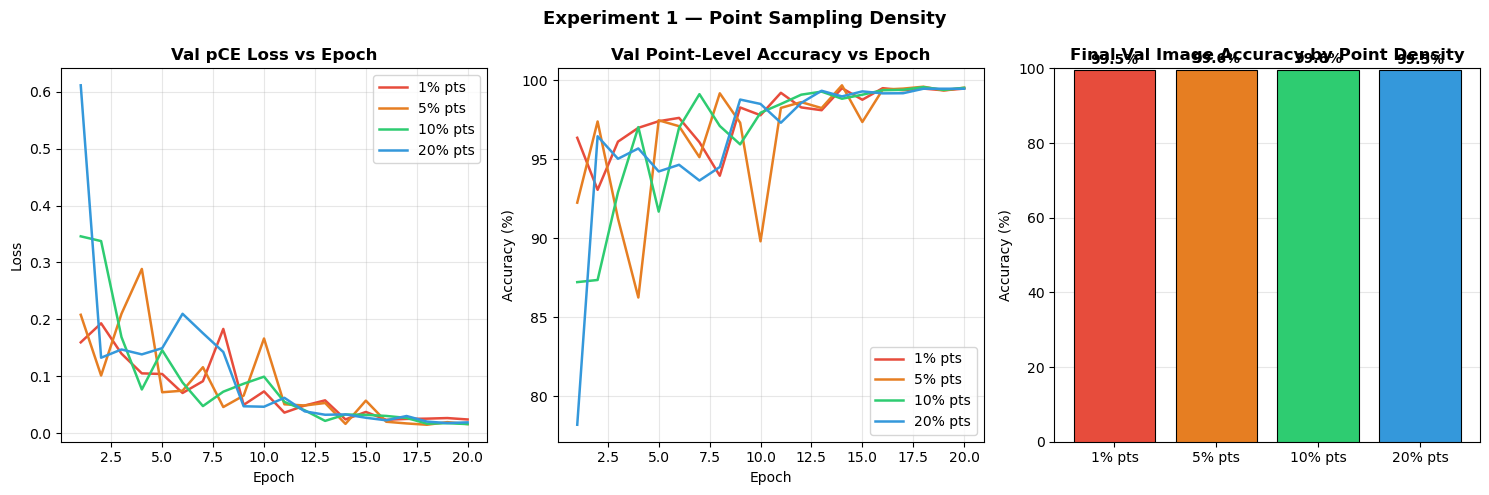

Saved: exp1_point_density.png


In [39]:
# plot the first experiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ep = list(range(1, EPOCHS + 1))
colors_exp = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"] #I googled some nice colors for the plots.
labels_exp = [f"{int(r*100)}% pts" for r in POINT_RATES]

# validation loss
for pr, col, lbl in zip(POINT_RATES, colors_exp, labels_exp):
    axes[0].plot(ep, exp1_results[pr]["val_loss"], color=col, label=lbl, linewidth=1.8)
axes[0].set_title("Val pCE Loss vs Epoch", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# point accuracy
for pr, col, lbl in zip(POINT_RATES, colors_exp, labels_exp):
    axes[1].plot(ep, [v*100 for v in exp1_results[pr]["val_pt_acc"]],
                 color=col, label=lbl, linewidth=1.8)
axes[1].set_title("Val Point-Level Accuracy vs Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# final image accuracy
final_img_accs = [exp1_results[pr]["val_img_acc"][-1]*100 for pr in POINT_RATES]
bars = axes[2].bar(labels_exp, final_img_accs, color=colors_exp, edgecolor="black",
                   linewidth=0.8, zorder=3)
axes[2].set_title("Final Val Image Accuracy by Point Density", fontweight="bold")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(0, 100)
axes[2].grid(True, axis="y", alpha=0.3, zorder=0)
for bar, val in zip(bars, final_img_accs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Experiment 1 — Point Sampling Density", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp1_point_density.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: exp1_point_density.png")


In [40]:
# print a small summary
print("\n Experiment 1 Summary ")
print(f"{'Point Rate':>12} | {'Final Val Loss':>16} | {'Pt Acc (%)':>12} | {'Img Acc (%)':>12}")
print("-" * 60)
for pr in POINT_RATES:
    h = exp1_results[pr]
    print(f"{pr*100:>11.0f}% | {h['val_loss'][-1]:>16.4f} | "
          f"{h['val_pt_acc'][-1]*100:>12.1f} | {h['val_img_acc'][-1]*100:>12.1f}")



 Experiment 1 Summary 
  Point Rate |   Final Val Loss |   Pt Acc (%) |  Img Acc (%)
------------------------------------------------------------
          1% |           0.0239 |         99.5 |         99.5
          5% |           0.0158 |         99.5 |         99.6
         10% |           0.0158 |         99.5 |         99.6
         20% |           0.0188 |         99.5 |         99.5


## Experiment 2 — Comparing the loss functions

**Question:** Does the way we handle the unlabeled pixels make a noticeable difference?

**Hypothesis:** Standard CE with "ignore_index=-1" and pCE with "gamma=0" should be very similar because both use only the labelled pixels. Adding focal weighting may help the model spend more of its loss on harder examples.

**Setup:** The point rate is fixed at 0.05 and three versions are compared:

- Standard CE with "ignore_index=-1"
- Partial CE with "gamma=0"
- Partial CE with focal weighting using "gamma=2"

Everything else I keep the same.


In [41]:
class StandardCEWithIgnore(nn.Module):
    
    # Standard CE baseline. Pixels with a target of -1 are ignored.
    
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets, point_mask=None):
        # ignore the unlabeled pixels
        # flatten before calling cross_entropy
        B, C, H, W = logits.shape
        logits_flat  = logits.permute(0, 2, 3, 1).reshape(-1, C)
        targets_flat = targets.reshape(-1)
        return F.cross_entropy(logits_flat, targets_flat, ignore_index=-1)


In [42]:
SPARSE_RATE = 0.05

EXP2_CONFIGS = {
    "Standard CE (ignore=-1)": {"loss": StandardCEWithIgnore(), "focal_gamma": None},
    "Partial CE (γ=0)": {"loss": PartialCrossEntropyLoss(focal_gamma=0.0), "focal_gamma": 0.0},
    "Partial CE + Focal (γ=2)": {"loss": PartialCrossEntropyLoss(focal_gamma=2.0), "focal_gamma": 2.0},
}

exp2_results = {}

for name, cfg in EXP2_CONFIGS.items():
    print(f"\n--- {name} ---")
    # run_experiment uses focal_gamma to init the loss internally,
    # but here we want to pass a pre-built loss object, so we inline the loop
    train_ds = RemoteSensingDataset(train_samples, img_size=IMG_SIZE,
                                    point_rate=SPARSE_RATE, augment=True)
    val_ds   = RemoteSensingDataset(val_samples, img_size=IMG_SIZE,
                                    point_rate=SPARSE_RATE, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    model    = PointSegNet(num_classes=NUM_CLASSES, pretrained=True).to(device)
    loss_fn  = cfg["loss"]
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_pt_acc": [], "val_img_acc": []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        v_loss, v_pt_acc, v_img_acc = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v_loss)
        history["val_pt_acc"].append(v_pt_acc)
        history["val_img_acc"].append(v_img_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{EPOCHS} | Train {tr_loss:.4f} | "
                  f"Val {v_loss:.4f} | Img Acc {v_img_acc*100:.1f}%")

    exp2_results[name] = history

print("\nDone.")



--- Standard CE (ignore=-1) ---


  Epoch   1/20 | Train 0.3574 | Val 0.1902 | Img Acc 93.7%
  Epoch   5/20 | Train 0.1586 | Val 0.0948 | Img Acc 95.5%
  Epoch  10/20 | Train 0.0834 | Val 0.0523 | Img Acc 98.1%
  Epoch  15/20 | Train 0.0490 | Val 0.0363 | Img Acc 98.8%
  Epoch  20/20 | Train 0.0305 | Val 0.0196 | Img Acc 99.6%

--- Partial CE (γ=0) ---
  Epoch   1/20 | Train 0.3648 | Val 0.1369 | Img Acc 96.1%
  Epoch   5/20 | Train 0.1572 | Val 0.2196 | Img Acc 91.3%
  Epoch  10/20 | Train 0.0978 | Val 0.0603 | Img Acc 98.3%
  Epoch  15/20 | Train 0.0471 | Val 0.0240 | Img Acc 99.3%
  Epoch  20/20 | Train 0.0242 | Val 0.0173 | Img Acc 99.6%

--- Partial CE + Focal (γ=2) ---
  Epoch   1/20 | Train 0.1142 | Val 0.1143 | Img Acc 89.5%
  Epoch   5/20 | Train 0.0546 | Val 0.0575 | Img Acc 94.8%
  Epoch  10/20 | Train 0.0356 | Val 0.0249 | Img Acc 97.2%
  Epoch  15/20 | Train 0.0154 | Val 0.0109 | Img Acc 98.8%
  Epoch  20/20 | Train 0.0070 | Val 0.0064 | Img Acc 99.7%

Done.


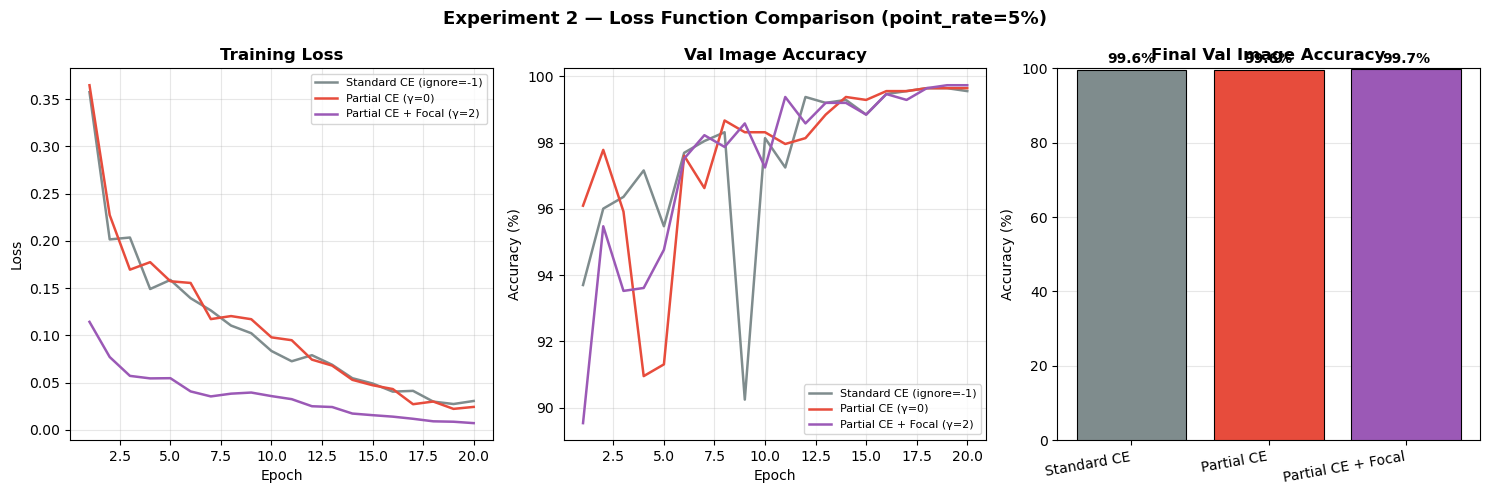

Saved: exp2_loss_comparison.png


In [43]:
# plot the second experiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ep = list(range(1, EPOCHS + 1))
colors_exp2 = ["#7f8c8d", "#e74c3c", "#9b59b6"]
names = list(exp2_results.keys())

for name, col in zip(names, colors_exp2):
    h = exp2_results[name]
    axes[0].plot(ep, h["train_loss"], color=col, label=name, linewidth=1.8)
    axes[1].plot(ep, [v*100 for v in h["val_img_acc"]], color=col, label=name, linewidth=1.8)

axes[0].set_title("Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Val Image Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# compare the final accuracies
final_accs = [exp2_results[n]["val_img_acc"][-1]*100 for n in names]
bars = axes[2].bar(range(len(names)), final_accs, color=colors_exp2,
                   edgecolor="black", linewidth=0.8, zorder=3)
axes[2].set_xticks(range(len(names)))
axes[2].set_xticklabels([n.split("(")[0].strip() for n in names], rotation=10, ha="right")
axes[2].set_title("Final Val Image Accuracy", fontweight="bold")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(0, 100)
axes[2].grid(True, axis="y", alpha=0.3, zorder=0)
for bar, val in zip(bars, final_accs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle(f"Experiment 2 — Loss Function Comparison (point_rate={SPARSE_RATE*100:.0f}%)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp2_loss_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: exp2_loss_comparison.png")


In [44]:
print("\n Experiment 2 Summary ")
print(f"{'Config':>40} | {'Train Loss':>12} | {'Img Acc (%)':>12}")
print("-" * 70)
for name in names:
    h = exp2_results[name]
    print(f"{name:>40} | {h['train_loss'][-1]:>12.4f} | {h['val_img_acc'][-1]*100:>12.1f}")



 Experiment 2 Summary 
                                  Config |   Train Loss |  Img Acc (%)
----------------------------------------------------------------------
                 Standard CE (ignore=-1) |       0.0305 |         99.6
                        Partial CE (γ=0) |       0.0242 |         99.6
                Partial CE + Focal (γ=2) |       0.0070 |         99.7


## Qualitative results

Here I take one validation image from each class and compare the input with the segmentation predicted by the main model.


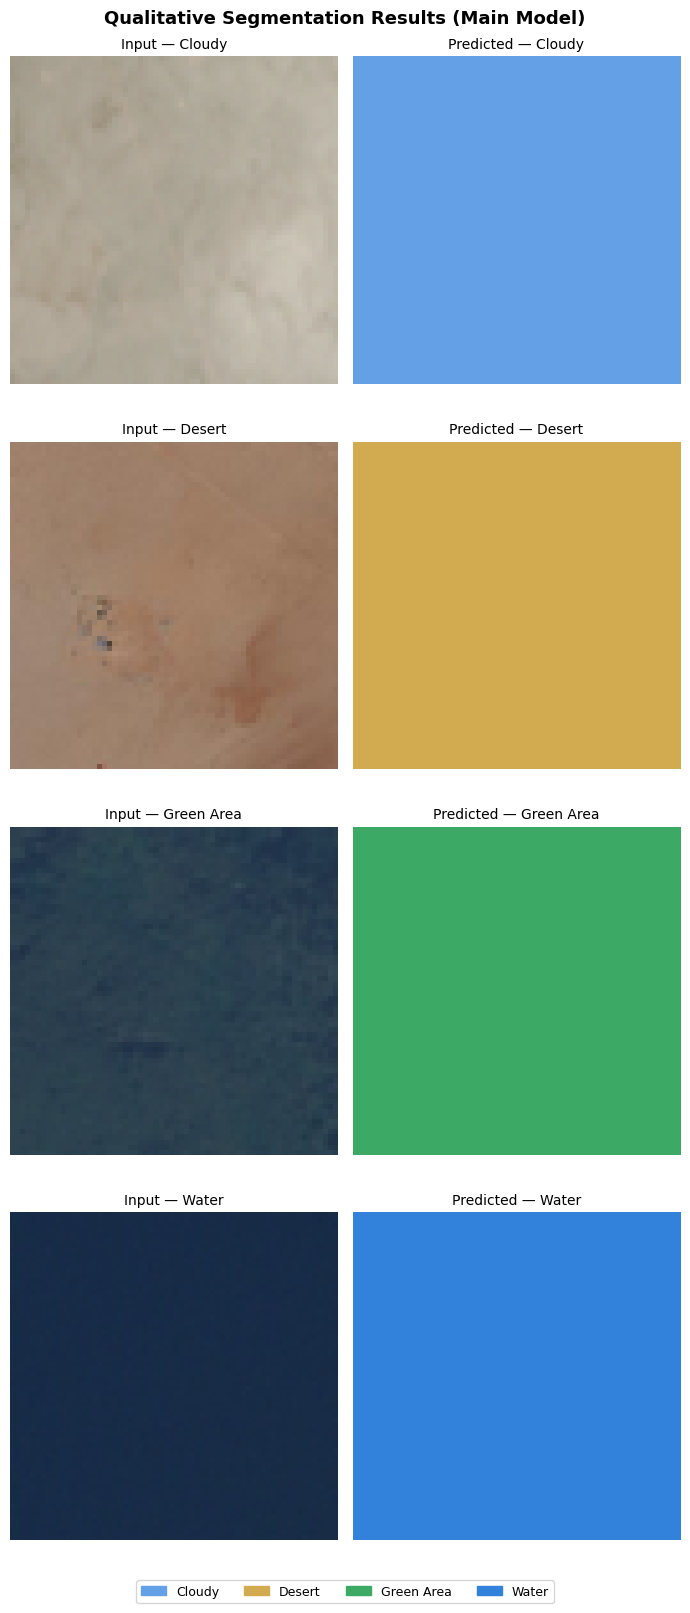

Saved: qualitative_results.png


In [45]:
@torch.no_grad()
def predict_segmap(model, img_path, img_size=64):
    # Run the model on one image and return the image and predicted map.
    model.eval()
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    img_pil = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    img_t   = normalize(TF.to_tensor(img_pil)).unsqueeze(0).to(device)
    logits  = model(img_t)
    pred    = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    return np.array(img_pil), pred


# colours used for the class map
CLASS_COLORS = np.array([
    [100, 160, 230],   # cloudy  — steel blue
    [210, 170,  80],   # desert  — sandy
    [ 60, 170, 100],   # green   — forest green
    [ 50, 130, 220],   # water   — ocean blue
], dtype=np.uint8)


def colorize_pred(pred_map):
    # Turn the predicted class IDs into an RGB image.
    H, W = pred_map.shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)
    for cls_idx in range(NUM_CLASSES):
        rgb[pred_map == cls_idx] = CLASS_COLORS[cls_idx]
    return rgb


# choose one validation image from each class
viz_samples = []
for cls in CLASS_NAMES:
    cls_samples = [(p, l) for p, l in val_samples if l == CLASS_TO_IDX[cls]]
    if cls_samples:
        viz_samples.append(random.choice(cls_samples))

fig, axes = plt.subplots(len(viz_samples), 2, figsize=(7, 4 * len(viz_samples)))

legend_patches = [mpatches.Patch(color=np.array(CLASS_COLORS[i])/255,
                                  label=CLASS_NAMES[i].replace("_", " ").title())
                  for i in range(NUM_CLASSES)]

for row, (path, true_label) in enumerate(viz_samples):
    img_np, pred_map = predict_segmap(main_model, path, img_size=IMG_SIZE)
    pred_rgb         = colorize_pred(pred_map)

    # most common predicted class
    dominant_cls = np.bincount(pred_map.flatten()).argmax()

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Input — {CLASS_NAMES[true_label].replace('_',' ').title()}", fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_rgb)
    axes[row, 1].set_title(
        f"Predicted — {CLASS_NAMES[dominant_cls].replace('_',' ').title()}", fontsize=10
    )
    axes[row, 1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle("Qualitative Segmentation Results (Main Model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("qualitative_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: qualitative_results.png")


In [46]:
# save the trained model
torch.save(main_model.state_dict(), "point_seg_net_main.pth")
print("Model saved to point_seg_net_main.pth")


Model saved to point_seg_net_main.pth
